Dati caricati con successo: 40000 righe
Agenti unici identificati: 20000
Decisioni di emigrazione registrate: 745
Osservazioni totali per analisi longitudinali: 40000
Caratteristiche iniziali agenti: 20000
Tasso emigrazione lifetime: 3.6%


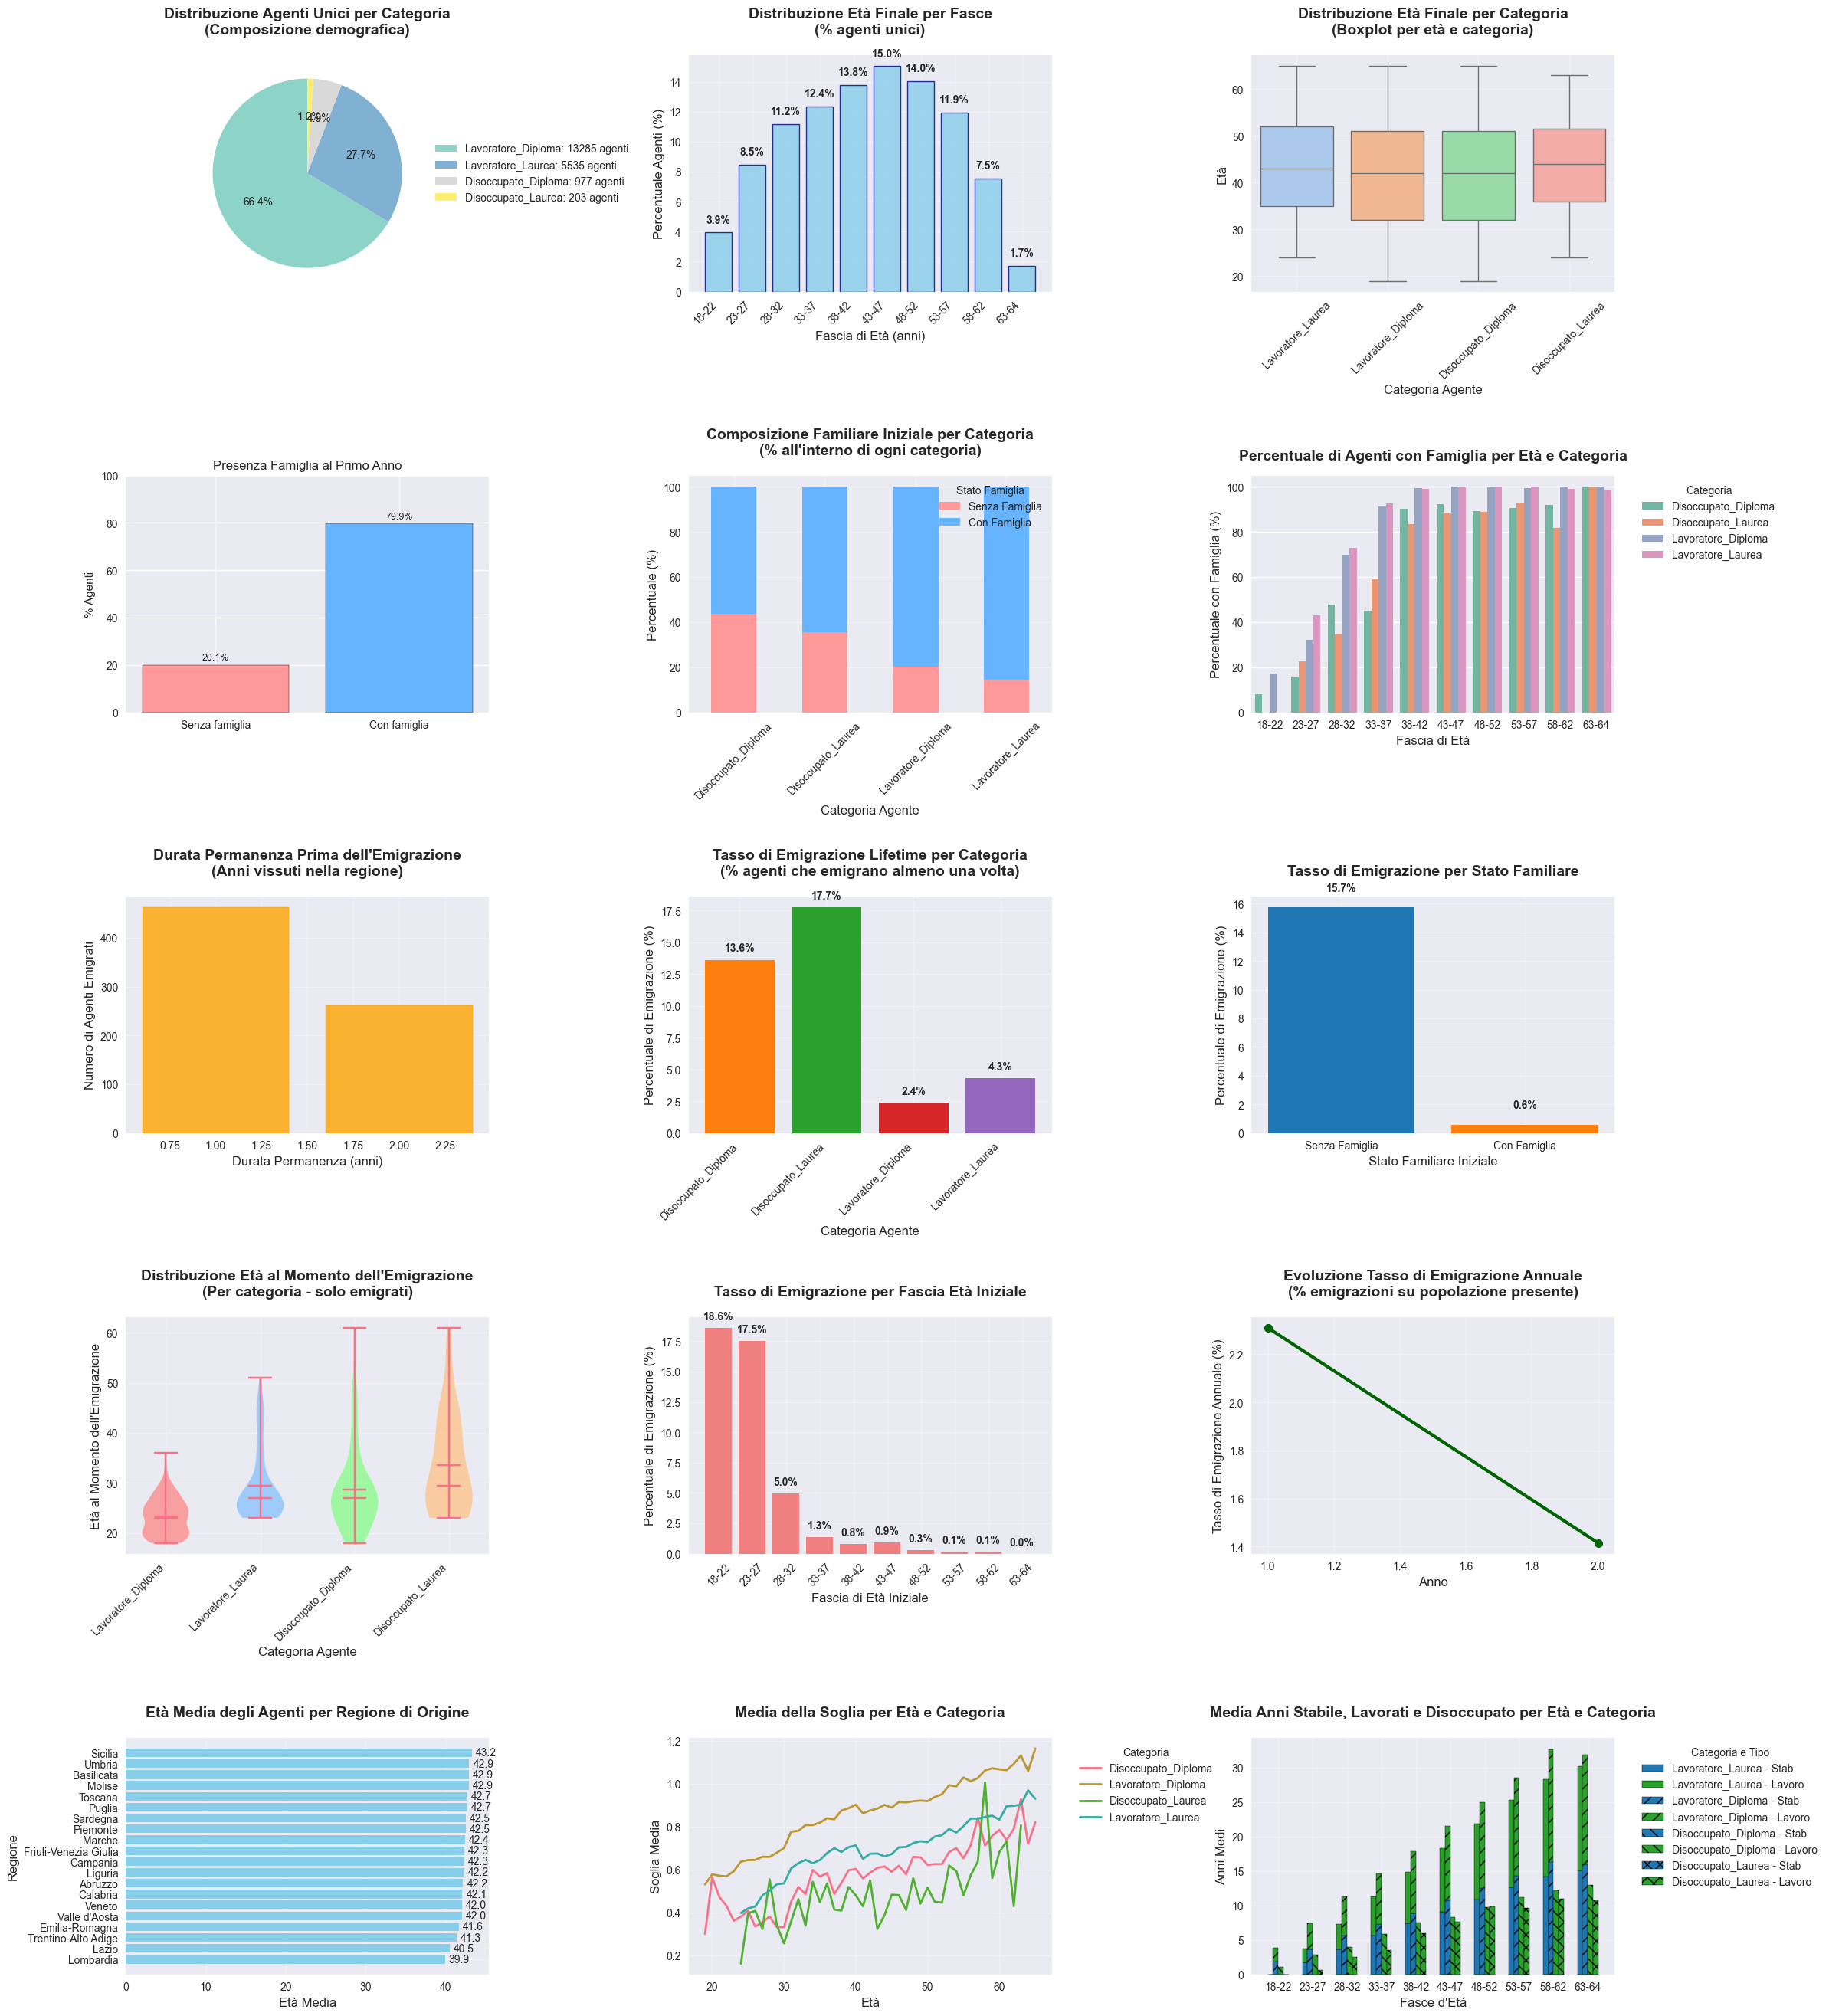

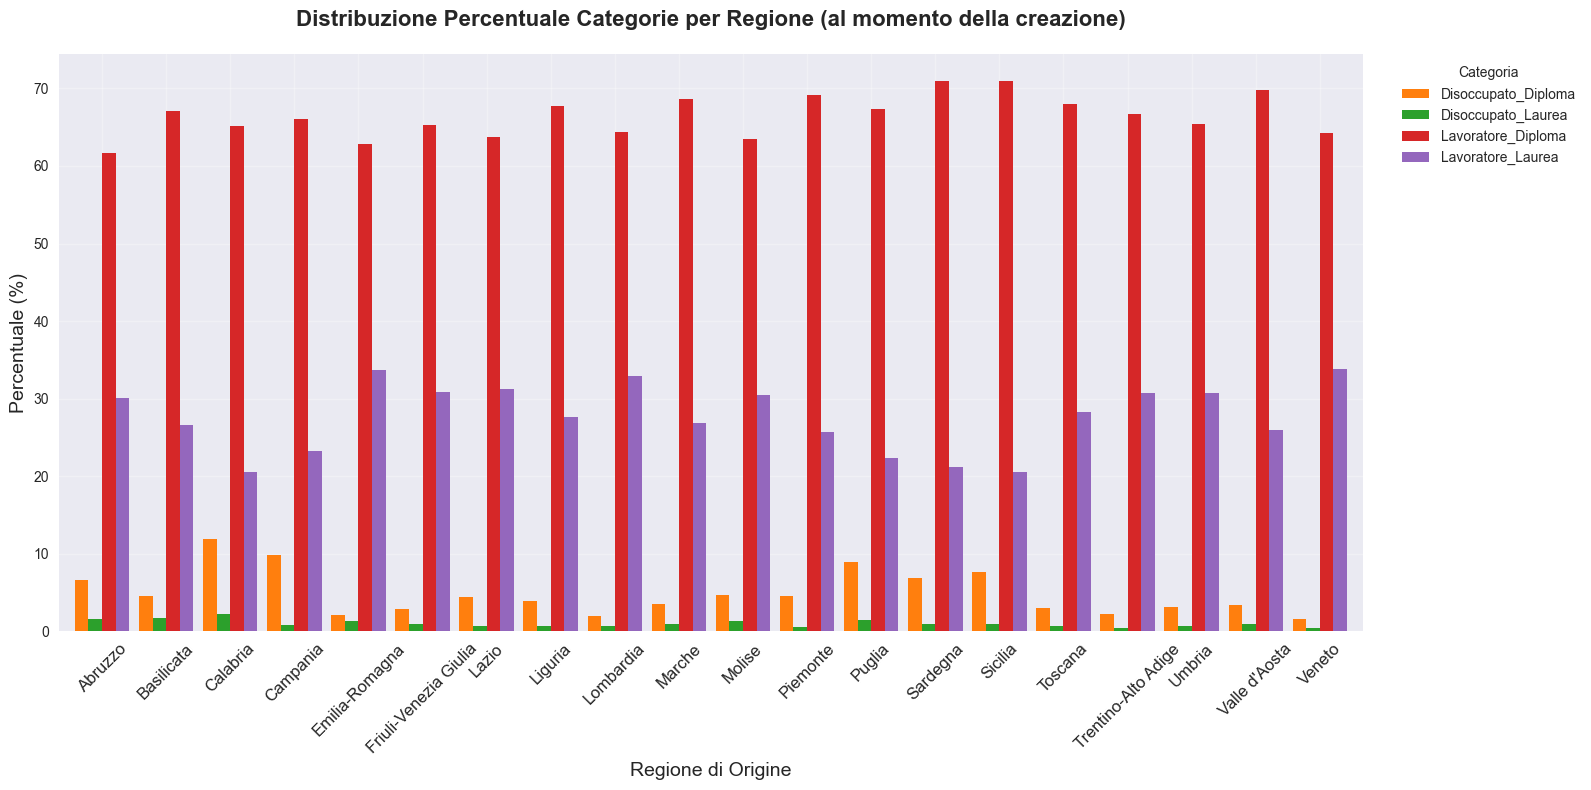

In [3]:
# Analisi Dati Migrazione - log.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

# Configurazione per visualizzazioni
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# ============================================================================
# PARAMETRI
# ============================================================================

N_AGENTI_PER_REGIONE = 1000 #Numero di agenti per regione
PERCENTUALE_SOGLIA = 1000    # Soglia percentuale per analisi 
ETA_MIN = 18              # Età minima agenti
ETA_MAX = 64              # Età massima agenti
N_CATEGORIE = 4           # Numero di categorie

COORDINATE_REGIONI = {
    'Abruzzo': (42.3511, 13.3994),
    'Basilicata': (40.6401, 15.8063),
    'Calabria': (39.3094, 16.2518),
    'Campania': (40.8359, 14.2488),
    'Emilia-Romagna': (44.4949, 11.3426),
    'Friuli-Venezia Giulia': (45.6361, 13.8047),
    'Lazio': (41.9028, 12.4964),
    'Liguria': (44.4056, 8.9463),
    'Lombardia': (45.4642, 9.1900),
    'Marche': (43.6158, 13.5189),
    'Molise': (41.7010, 14.4722),
    'Piemonte': (45.0703, 7.6869),
    'Puglia': (41.1257, 16.8765),
    'Sardegna': (40.1209, 9.0129),
    'Sicilia': (37.5999, 14.0154),
    'Toscana': (43.7711, 11.2486),
    'Trentino-Alto Adige': (46.4982, 11.3548),
    'Umbria': (42.9382, 12.6144),
    'Valle d\'Aosta': (45.7383, 7.3514),
    'Veneto': (45.4398, 12.3317)
}

# ============================================================================
# CARICAMENTO E PREPARAZIONE 
# ============================================================================


try:
    df_raw = pd.read_csv('../Simulation/data/log.csv')
    print(f"Dati caricati con successo: {len(df_raw)} righe")
except FileNotFoundError:
    print("File log.csv non trovato nella cartella superiore")
except Exception as e:
    print(f"Errore nel caricamento: {e}")

# Gestione valori mancanti
if df_raw.isnull().sum().sum() > 0:
    print("Valori mancanti trovati:")
    print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])
    df_raw = df_raw.dropna()
    print(f"Righe dopo pulizia: {len(df_raw)}")


# 1. DATASET AGENTI UNICI (per analisi demografiche)
# l'ultima osservazione di ogni agente per avere dati demografici finali
df_agenti_unici = df_raw.sort_values(['id_agente', 'anno']).groupby('id_agente').last().reset_index()
print(f"Agenti unici identificati: {len(df_agenti_unici)}")

# 2. DATASET DECISIONI MIGRATORIE (solo righe con emigrato=True)
df_emigrazioni = df_raw[df_raw['emigrato'] == True].copy()
print(f"Decisioni di emigrazione registrate: {len(df_emigrazioni)}")

# 3. DATASET COMPLETO per analisi temporali
df_longitudinale = df_raw.copy()
print(f"Osservazioni totali per analisi longitudinali: {len(df_longitudinale)}")

# 4. DATASET PER SURVIVAL ANALYSIS (primo anno di ogni agente)
df_primo_anno = df_raw.sort_values(['id_agente', 'anno']).groupby('id_agente').first().reset_index()
print(f"Caratteristiche iniziali agenti: {len(df_primo_anno)}")

# Calcoliamo chi ha mai emigrato nella sua "vita"
agenti_emigrati = set(df_emigrazioni['id_agente'].unique())
df_agenti_unici['mai_emigrato'] = df_agenti_unici['id_agente'].isin(agenti_emigrati)
df_primo_anno['mai_emigrato'] = df_primo_anno['id_agente'].isin(agenti_emigrati)

# Creazione fasce d'età sui dati unici
bins = [17, 22, 27, 32, 37, 42, 47, 52, 57, 62, 65]
labels = ['18-22', '23-27', '28-32', '33-37', '38-42', '43-47', '48-52', '53-57', '58-62', '63-64']
df_agenti_unici['fascia_eta'] = pd.cut(df_agenti_unici['eta'], bins=bins, labels=labels, include_lowest=True)
df_primo_anno['fascia_eta'] = pd.cut(df_primo_anno['eta'], bins=bins, labels=labels, include_lowest=True)

print(f"Tasso emigrazione lifetime: {df_agenti_unici['mai_emigrato'].mean()*100:.1f}%")


# ============================================================================
# VISUALIZZAZIONI STATICHE - ANALISI LONGITUDINALE CORRETTA
# ============================================================================


fig = plt.figure(figsize=(24, 32))

# =============================================================================
# SEZIONE 1: ANALISI DEMOGRAFICA GENERALE (su agenti unici)
# =============================================================================

# 1. Distribuzione categorie (su agenti unici)
ax1 = plt.subplot(6, 3, 1)
cat_counts = df_agenti_unici['categoria'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(cat_counts)))
wedges, texts, autotexts = ax1.pie(cat_counts.values, labels=None, 
                                    autopct='%1.1f%%', startangle=90, colors=colors)
ax1.legend(wedges, [f'{cat}: {count} agenti' for cat, count in cat_counts.items()], 
        loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
ax1.set_title('Distribuzione Agenti Unici per Categoria\n(Composizione demografica)', 
            fontsize=14, fontweight='bold', pad=20)


# Età massima inclusa: 64 anni
df_età_filtrato = df_agenti_unici[df_agenti_unici['eta'] <= 65]



ax2 = plt.subplot(6, 3, 2)
fascia_counts = df_agenti_unici['fascia_eta'].value_counts().sort_index()
percentuali = (fascia_counts / len(df_agenti_unici)) * 100
bars = ax2.bar(range(len(percentuali)), percentuali, alpha=0.8, color='skyblue', edgecolor='navy', linewidth=1)
ax2.set_title('Distribuzione Età Finale per Fasce\n(% agenti unici)', fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Fascia di Età (anni)', fontsize=12)
ax2.set_ylabel('Percentuale Agenti (%)', fontsize=12)
ax2.set_xticks(range(len(percentuali)))
ax2.set_xticklabels(fascia_counts.index, rotation=45, ha='right')
ax2.grid(True, alpha=0.3)
for bar, val in zip(bars, percentuali):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')


#  GRAFICO 3: Distribuzione età per categoria
ax3 = plt.subplot(6, 3, 3)
sns.boxplot(data=df_agenti_unici, x='categoria', y='eta', palette='pastel', ax=ax3)
ax3.set_title('Distribuzione Età Finale per Categoria\n(Boxplot per età e categoria)', 
            fontsize=14, fontweight='bold', pad=20)
ax3.set_xlabel('Categoria Agente', fontsize=12)
ax3.set_ylabel('Età', fontsize=12)
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3)



# 4. Percentuale con/senza famiglia al primo anno (usando df_primo_anno)
ax4 = plt.subplot(6, 3, 4)
famiglia_counts = df_primo_anno['famiglia'].value_counts().sort_index()
labels = ['Senza famiglia', 'Con famiglia']
values = [famiglia_counts.get(0, 0), famiglia_counts.get(1, 0)]
percentuali = [v / sum(values) * 100 for v in values]
bar_colors = ['#FF9999', '#66B3FF']
bars = ax4.bar(labels, percentuali, color=bar_colors, edgecolor='black')

# Etichette sopra le barre
for bar, perc in zip(bars, percentuali):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{perc:.1f}%", 
             ha='center', va='bottom', fontsize=9)
ax4.set_ylim(0, 100)
ax4.set_ylabel('% Agenti')
ax4.set_title('Presenza Famiglia al Primo Anno')



# Distribuzione famiglia per categoria (caratteristiche iniziali)
ax6 = plt.subplot(6, 3, 5)
df_cat_fam = df_primo_anno.groupby(['categoria', 'famiglia']).size().unstack(fill_value=0)
df_cat_fam_pct = df_cat_fam.div(df_cat_fam.sum(axis=1), axis=0) * 100

df_cat_fam_pct.plot(kind='bar', stacked=True, ax=ax6, color=['#ff9999', '#66b3ff'])
ax6.set_title('Composizione Familiare Iniziale per Categoria\n(% all\'interno di ogni categoria)', 
            fontsize=14, fontweight='bold', pad=20)
ax6.set_xlabel('Categoria Agente', fontsize=12)
ax6.set_ylabel('Percentuale (%)', fontsize=12)
ax6.legend(['Senza Famiglia', 'Con Famiglia'], title='Stato Famiglia')
ax6.tick_params(axis='x', rotation=45)
ax6.grid(True, alpha=0.3)


df_agenti_unici['famiglia'] = df_agenti_unici['famiglia'].astype(int)

# Calcola la media (percentuale) di agenti con famiglia per fascia_eta, categoria, e regione (origine)
grouped = df_agenti_unici.groupby(['fascia_eta', 'categoria', 'origine'])['famiglia'].mean().reset_index()
grouped['percentuale_famiglia'] = grouped['famiglia'] * 100

# Posizioniamo il grafico come subplot 12 (riga 4, colonna 3)
ax12 = plt.subplot(6, 3, 6)

sns.barplot(
    data=grouped,
    x='fascia_eta',
    y='percentuale_famiglia',
    hue='categoria',
    palette='Set2',
    errorbar=None,
    ax=ax12
)

ax12.set_title('Percentuale di Agenti con Famiglia per Età e Categoria', fontsize=14, fontweight='bold', pad=15)
ax12.set_xlabel('Fascia di Età', fontsize=12)
ax12.set_ylabel('Percentuale con Famiglia (%)', fontsize=12)
ax12.legend(title='Categoria', bbox_to_anchor=(1.05, 1), loc='upper left')


# =============================================================================
# SEZIONE 2: ANALISI SURVIVAL/DURATA PERMANENZA
# =============================================================================

# 4. Distribuzione durata permanenza per agenti emigrati
ax4 = plt.subplot(6, 3, 7)
# Calcoliamo per ogni agente emigrato, quanti anni è rimasto
durata_permanenza = []
for agente in agenti_emigrati:
    osservazioni_agente = df_raw[df_raw['id_agente'] == agente].sort_values('anno')
    anno_emigrazione = osservazioni_agente[osservazioni_agente['emigrato'] == True]['anno'].iloc[0]
    primo_anno = osservazioni_agente['anno'].min()
    durata = anno_emigrazione - primo_anno + 1  # +1 perché include l'anno di emigrazione
    durata_permanenza.append(durata)

durata_counts = Counter(durata_permanenza)
anni = sorted(durata_counts.keys())
frequenze = [durata_counts[anno] for anno in anni]

bars = ax4.bar(anni, frequenze, alpha=0.8, color='orange', edgecolor='darkorange')
ax4.set_title('Durata Permanenza Prima dell\'Emigrazione\n(Anni vissuti nella regione)', 
            fontsize=14, fontweight='bold', pad=20)
ax4.set_xlabel('Durata Permanenza (anni)', fontsize=12)
ax4.set_ylabel('Numero di Agenti Emigrati', fontsize=12)
ax4.grid(True, alpha=0.3)


# =============================================================================
# SEZIONE 3: ANALISI PATTERN MIGRATORI (lifetime migration)
# =============================================================================

# 7. Tasso emigrazione lifetime per categoria
ax7 = plt.subplot(6, 3, 8)
emigrazione_cat = df_agenti_unici.groupby('categoria')['mai_emigrato'].mean() * 100
bars = ax7.bar(range(len(emigrazione_cat)), emigrazione_cat.values, 
                color=['#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
ax7.set_title('Tasso di Emigrazione Lifetime per Categoria\n(% agenti che emigrano almeno una volta)', 
            fontsize=14, fontweight='bold', pad=20)
ax7.set_xlabel('Categoria Agente', fontsize=12)
ax7.set_ylabel('Percentuale di Emigrazione (%)', fontsize=12)
ax7.set_xticks(range(len(emigrazione_cat)))
ax7.set_xticklabels(emigrazione_cat.index, rotation=45, ha='right')
ax7.grid(True, alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, emigrazione_cat.values)):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

# 9. Emigrazione per stato familiare iniziale
ax9 = plt.subplot(6, 3, 9)
emigrazione_famiglia = df_primo_anno.groupby('famiglia')['mai_emigrato'].mean() * 100
bars = ax9.bar(['Senza Famiglia', 'Con Famiglia'], emigrazione_famiglia.values, 
                color=['#1f77b4', '#ff7f0e'])
ax9.set_title('Tasso di Emigrazione per Stato Familiare', 
            fontsize=14, fontweight='bold', pad=20)
ax9.set_xlabel('Stato Familiare Iniziale', fontsize=12)
ax9.set_ylabel('Percentuale di Emigrazione (%)', fontsize=12)
ax9.grid(True, alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, emigrazione_famiglia.values)):
    ax9.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')


# 11. Distribuzione età al momento dell'emigrazione
ax11 = plt.subplot(6, 3, 10)
if len(df_emigrazioni) > 0:
    categories = df_emigrazioni['categoria'].unique()
    colors_violin = ['#ff7f7f', '#7fbfff', '#7fff7f', '#ffbf7f']
    
    data_by_cat = [df_emigrazioni[df_emigrazioni['categoria'] == cat]['eta'].values for cat in categories]
    parts = ax11.violinplot(data_by_cat, positions=range(len(categories)), 
                        showmeans=True, showmedians=True)
    
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors_violin[i % len(colors_violin)])
        pc.set_alpha(0.7)
    
    ax11.set_title('Distribuzione Età al Momento dell\'Emigrazione\n(Per categoria - solo emigrati)', 
                fontsize=14, fontweight='bold', pad=20)
    ax11.set_xlabel('Categoria Agente', fontsize=12)
    ax11.set_ylabel('Età al Momento dell\'Emigrazione', fontsize=12)
    ax11.set_xticks(range(len(categories)))
    ax11.set_xticklabels(categories, rotation=45, ha='right')
    ax11.grid(True, alpha=0.3)


# 8. Tasso emigrazione per fascia d'età iniziale
ax8 = plt.subplot(6, 3, 11)
emigrazione_fascia = df_primo_anno.groupby('fascia_eta')['mai_emigrato'].mean() * 100
bars = ax8.bar(range(len(emigrazione_fascia)), emigrazione_fascia.values, color='lightcoral')
ax8.set_title('Tasso di Emigrazione per Fascia Età Iniziale', 
            fontsize=14, fontweight='bold', pad=20)
ax8.set_xlabel('Fascia di Età Iniziale', fontsize=12)
ax8.set_ylabel('Percentuale di Emigrazione (%)', fontsize=12)
ax8.set_xticks(range(len(emigrazione_fascia)))
ax8.set_xticklabels(emigrazione_fascia.index, rotation=45)
ax8.grid(True, alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, emigrazione_fascia.values)):
    ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')


# 10. Timeline emigrazioni per anno
ax10 = plt.subplot(6, 3, 12)
emigrazioni_anno = df_emigrazioni.groupby('anno').size()
# Calcoliamo anche la popolazione a rischio per anno
popolazione_anno = df_longitudinale.groupby('anno').size()
tasso_anno = (emigrazioni_anno / popolazione_anno * 100).fillna(0)

ax10.plot(tasso_anno.index, tasso_anno.values, marker='o', linewidth=3, markersize=8, color='darkgreen')
ax10.set_title('Evoluzione Tasso di Emigrazione Annuale\n(% emigrazioni su popolazione presente)', 
            fontsize=14, fontweight='bold', pad=20)
ax10.set_xlabel('Anno', fontsize=12)
ax10.set_ylabel('Tasso di Emigrazione Annuale (%)', fontsize=12)
ax10.grid(True, alpha=0.3)


# Grafico 13: Età media per regione di origine
ax13 = plt.subplot(6, 3, 13)

eta_media_regione = df_agenti_unici.groupby('origine')['eta'].mean().sort_values()
bars = ax13.barh(eta_media_regione.index, eta_media_regione.values, color='skyblue')

ax13.set_title('Età Media degli Agenti per Regione di Origine', 
               fontsize=14, fontweight='bold', pad=20)
ax13.set_xlabel('Età Media', fontsize=12)
ax13.set_ylabel('Regione', fontsize=12)
ax13.grid(True, alpha=0.3)

# Aggiunta delle etichette con i valori
for bar in bars:
    width = bar.get_width()
    ax13.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
              f'{width:.1f}', ha='left', va='center')

# Manteniamo il layout e mostriamo il grafico
plt.tight_layout(pad=3.0)

# Grafico 14: Media della soglia per età, per categoria (line plot continuo)
ax14 = plt.subplot(6, 3, 14)
# Calcolo della media della soglia per età e categoria
soglia_media_eta_cat = df_agenti_unici.groupby(['eta', 'categoria'])['soglia'].mean().reset_index()
# Plot delle linee per ogni categoria
for cat in soglia_media_eta_cat['categoria'].unique():
    data_cat = soglia_media_eta_cat[soglia_media_eta_cat['categoria'] == cat]
    ax14.plot(data_cat['eta'], data_cat['soglia'], label=cat, linewidth=2)
ax14.set_title('Media della Soglia per Età e Categoria', fontsize=14, fontweight='bold', pad=20)
ax14.set_xlabel('Età', fontsize=12)
ax14.set_ylabel('Soglia Media', fontsize=12)
ax14.legend(title='Categoria', bbox_to_anchor=(1.05, 1), loc='upper left')
ax14.grid(True, alpha=0.3)

# Grafico 15: Media Anni Stabile, Lavorati e Disoccupato per Età e Categoria
ax15 = plt.subplot(6, 3, 15)

# Riutilizziamo 'fascia_eta' e le categorie già esistenti
fasce_eta = df_agenti_unici['fascia_eta'].unique()
fasce_eta = sorted(fasce_eta, key=lambda x: int(x.split('-')[0]) if '-' in x else 100)  # Ordine logico
categorie = df_agenti_unici['categoria'].unique()

# Prepara l'aggregazione
df_agg = df_agenti_unici.groupby(['categoria', 'fascia_eta']).agg({
    'anni_stab': 'mean',
    'anni_lavoro': 'mean',

}).reset_index()

colori_anni = {
    'anni_stab': '#1f77b4',       # blu
    'anni_lavoro': '#2ca02c',     # verde
}

# Pattern per categoria
pattern_categoria = {
    cat: pattern for cat, pattern in zip(categorie, ['', '//', '\\\\', 'xx', 'oo', '--', '..'])
}

# Completa le combinazioni mancanti (categorie x fasce_eta)
index_completo = pd.MultiIndex.from_product([categorie, fasce_eta], names=['categoria', 'fascia_eta'])
df_agg = df_agg.set_index(['categoria', 'fascia_eta']).reindex(index_completo).fillna(0).reset_index()

# Preparazione x e plotting
bar_width = 0.15
x = np.arange(len(fasce_eta))
n_categorie = len(categorie)


for i, cat in enumerate(categorie):
    df_cat = df_agg[df_agg['categoria'] == cat]
    pos = x + i * bar_width
    bottom = np.zeros(len(x))

    for tipo_anno in ['anni_stab', 'anni_lavoro']:
        ax15.bar(
            pos,
            df_cat[tipo_anno],
            bar_width,
            bottom=bottom,
            label=f'{cat} - {tipo_anno.split("_")[1].capitalize()}',
            color=colori_anni[tipo_anno],
            hatch=pattern_categoria[cat],
            edgecolor='black',
            linewidth=0.3
        )
        bottom += df_cat[tipo_anno]



# Etichette e legenda
ax15.set_title('Media Anni Stabile, Lavorati e Disoccupato per Età e Categoria',
               fontsize=14, fontweight='bold', pad=20)
ax15.set_xlabel('Fasce d\'Età', fontsize=12)
ax15.set_ylabel('Anni Medi', fontsize=12)
ax15.set_xticks(x + (n_categorie - 1) * bar_width / 2)
ax15.set_xticklabels(fasce_eta)
ax15.grid(True, alpha=0.3)

# Legenda fuori dal grafico
handles, labels = ax15.get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))  # Rimuove duplicati
ax15.legend(unique_labels.values(), unique_labels.keys(), title='Categoria e Tipo',
            bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

fig_regioni_categorie = plt.figure(figsize=(16, 8))

df_cat_regione = df_primo_anno.groupby(['origine', 'categoria']).size().unstack(fill_value=0)
df_cat_regione_pct = df_cat_regione.div(df_cat_regione.sum(axis=1), axis=0) * 100

ax = plt.gca()
df_cat_regione_pct.plot(kind='bar', ax=ax, width=0.85, color=['#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

ax.set_title('Distribuzione Percentuale Categorie per Regione (al momento della creazione)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Regione di Origine', fontsize=14)
ax.set_ylabel('Percentuale (%)', fontsize=14)
ax.legend(title='Categoria', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45, labelsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

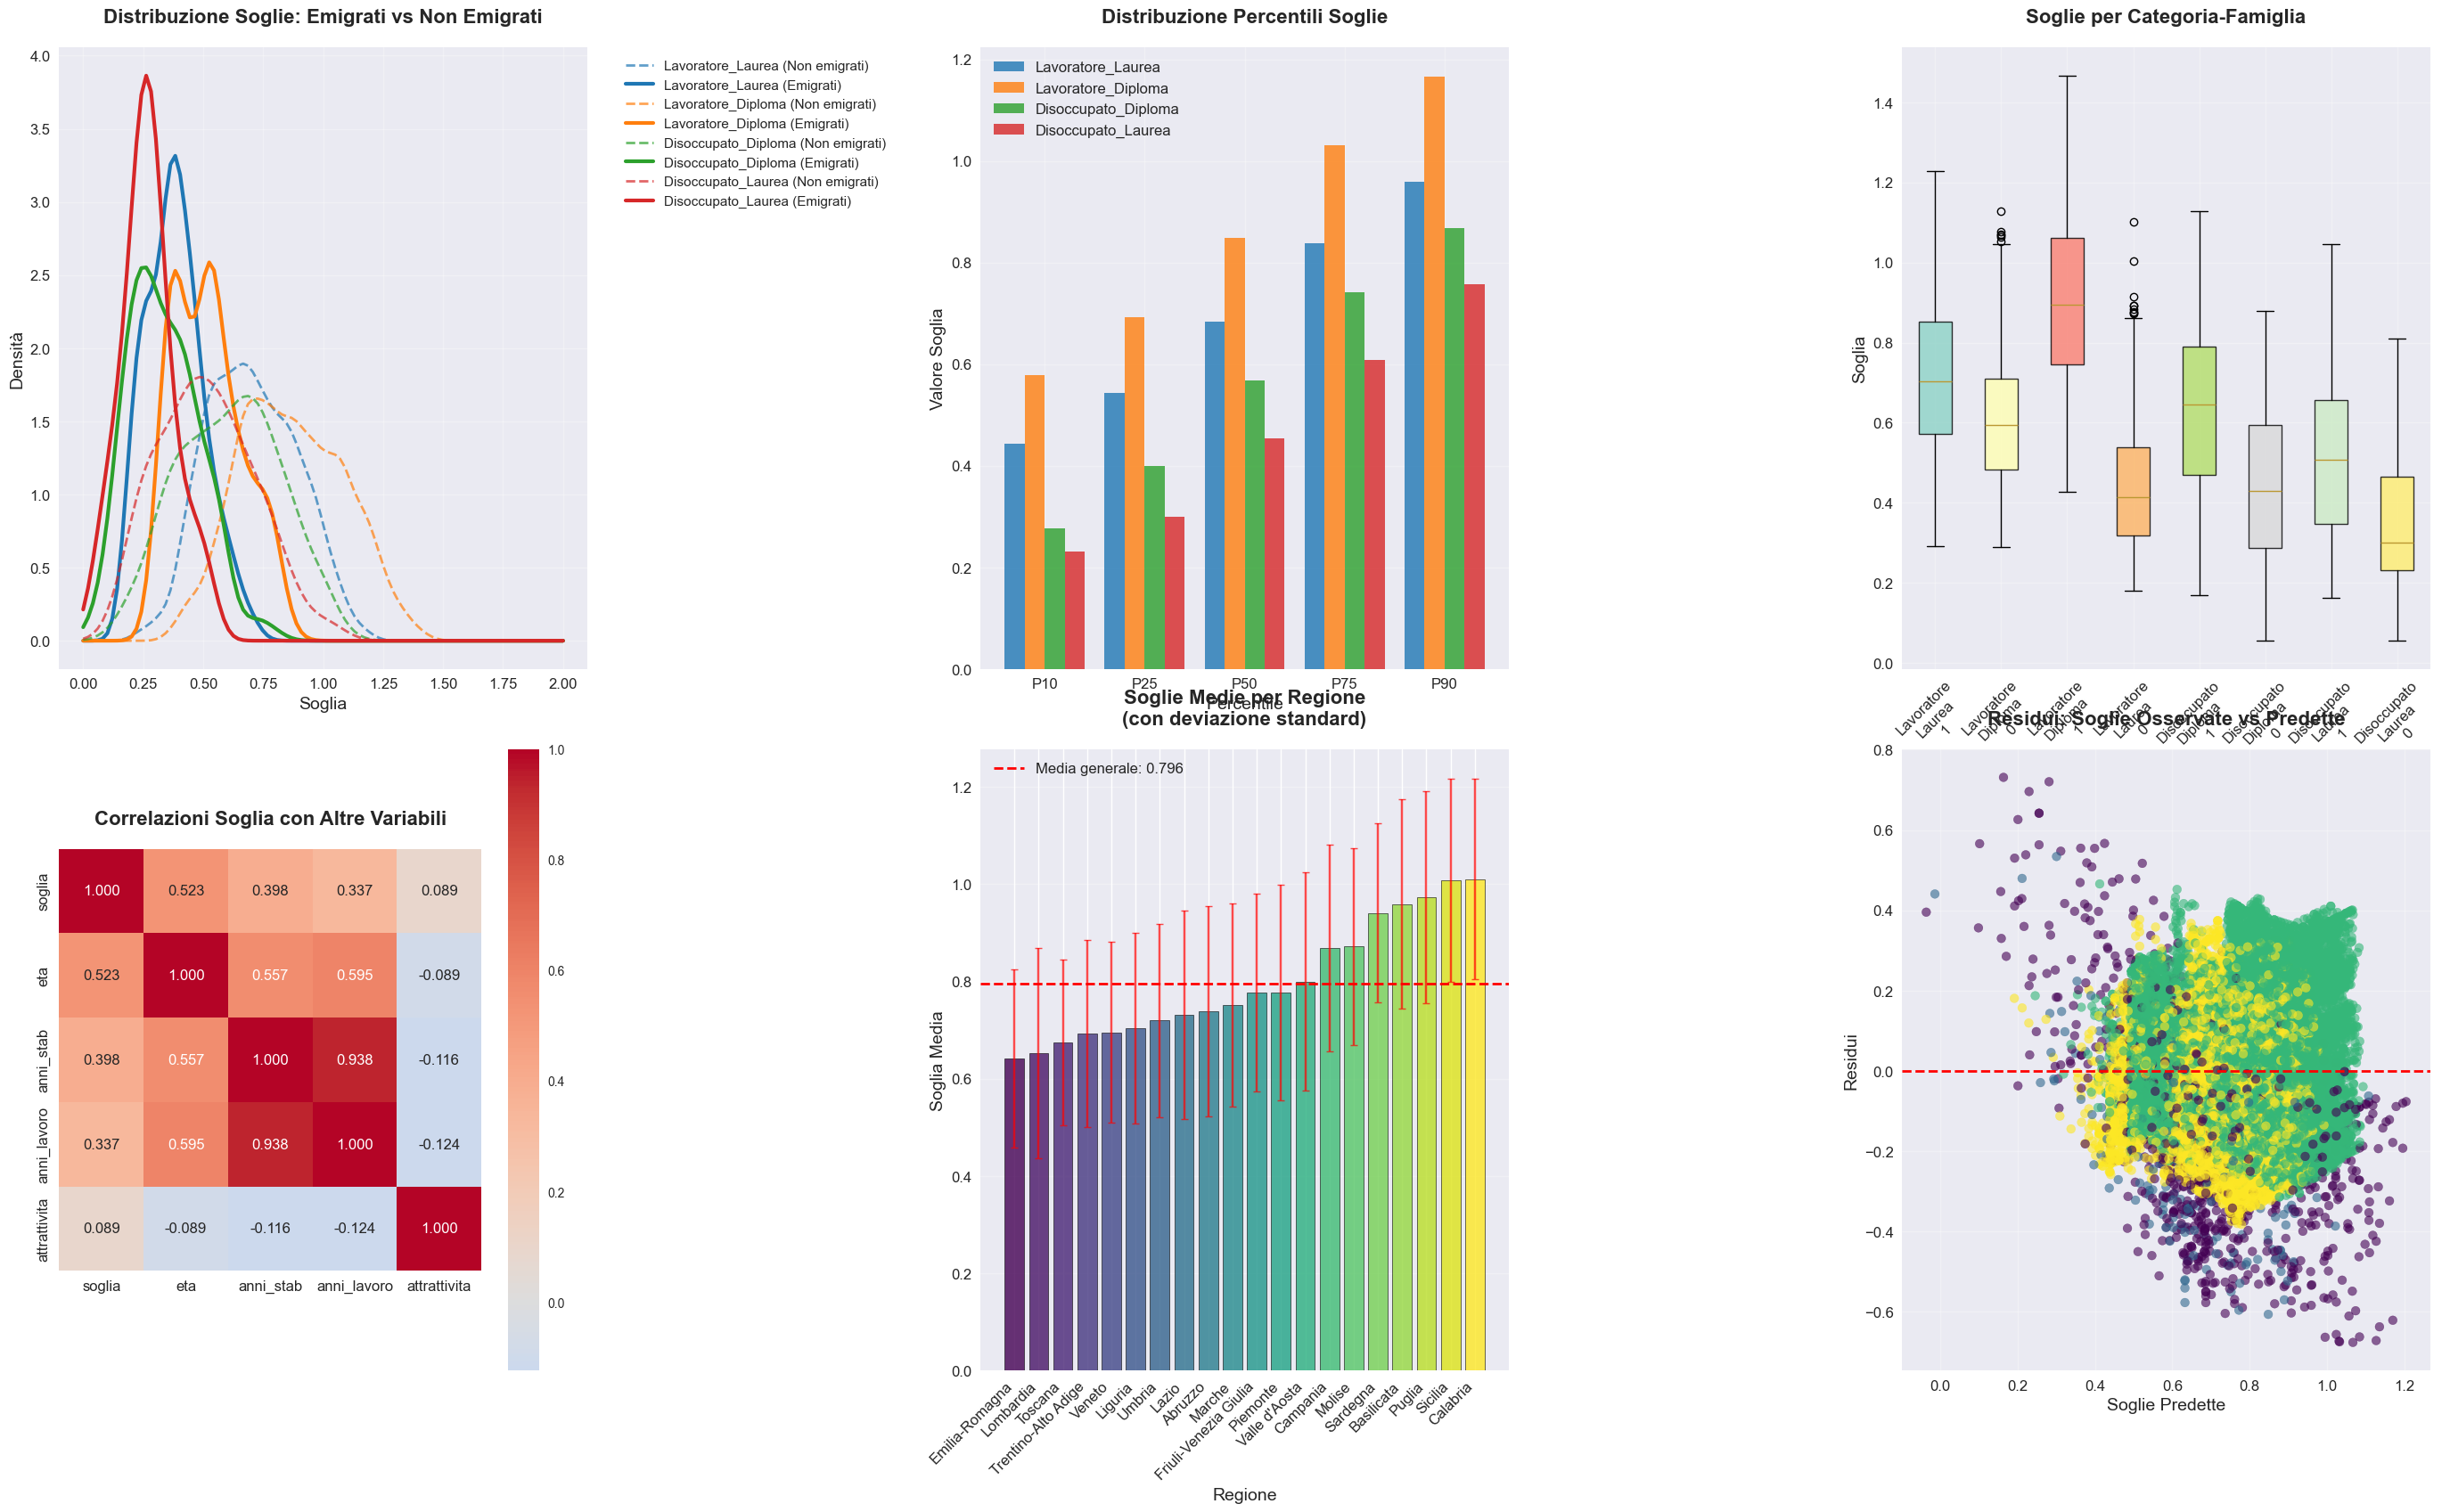

STATISTICHE RIASSUNTIVE SOGLIE DECISIONALI

1. STATISTICHE GENERALI PER CATEGORIA:
                     count    mean     std     min     max
categoria                                                 
Disoccupato_Diploma    977  0.5725  0.2235  0.0557  1.1282
Disoccupato_Laurea     203  0.4709  0.2067  0.0559  1.0453
Lavoratore_Diploma   13285  0.8610  0.2228  0.2889  1.4666
Lavoratore_Laurea     5535  0.6902  0.1959  0.1795  1.2275

2. TASSO EMIGRAZIONE PER QUARTILI DI SOGLIA:
                   mean  count  tasso_pct
quartile_soglia                          
Q1               0.1282   5000    12.8200
Q2               0.0132   5001     1.3197
Q3               0.0032   5003     0.3198
Q4               0.0000   4996     0.0000

3. CORRELAZIONI PRINCIPALI CON SOGLIA:
soglia          1.0000
eta             0.5232
anni_stab       0.3977
anni_lavoro     0.3366
attrattivita    0.0894
Name: soglia, dtype: float64

4. SOGLIE IDENTIFICATE:
- Soglia mediana generale: 0.783
- Soglia che separa il 

In [4]:
# ============================================================================
# ANALISI COMPLETA SOGLIE DECISIONALI - CELLA SEPARATA
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurazione
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Preparazione dati
agenti_emigrati_set = set(df_emigrazioni['id_agente'].unique())
df_analisi = df_agenti_unici.copy()
df_analisi['mai_emigrato'] = df_analisi['id_agente'].isin(agenti_emigrati_set)

# Creazione figura principale
fig = plt.figure(figsize=(28, 24))

# ============================================================================
# 2. DISTRIBUZIONE SOGLIE CON DENSITÀ SEPARATA EMIGRATI/NON EMIGRATI
# ============================================================================
ax2 = plt.subplot(3, 3, 1)

categories = df_analisi['categoria'].unique()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, cat in enumerate(categories):
    data_cat = df_analisi[df_analisi['categoria'] == cat]
    
    # Separazione emigrati/non emigrati
    non_emigrati = data_cat[~data_cat['mai_emigrato']]['soglia']
    emigrati = data_cat[data_cat['mai_emigrato']]['soglia']
    
    # Densità kernel per visualizzazione smooth
    if len(non_emigrati) > 5:
        density_non = stats.gaussian_kde(non_emigrati)
        xs = np.linspace(0, 2, 100)
        ax2.plot(xs, density_non(xs), '--', color=colors[i], alpha=0.7, 
                label=f'{cat} (Non emigrati)', linewidth=2)
    
    if len(emigrati) > 5:
        density_em = stats.gaussian_kde(emigrati)
        xs = np.linspace(0, 2, 100)
        ax2.plot(xs, density_em(xs), '-', color=colors[i], linewidth=3,
                label=f'{cat} (Emigrati)')

ax2.set_title('Distribuzione Soglie: Emigrati vs Non Emigrati', fontweight='bold', pad=20, fontsize=16)
ax2.set_xlabel('Soglia', fontsize=14)
ax2.set_ylabel('Densità', fontsize=14)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', which='major', labelsize=12)

# ============================================================================
# 2. SOGLIE VS CARATTERISTICHE CHIAVE (SCATTER MULTIVARIATO)
# ============================================================================
ax9 = plt.subplot(3, 3, 2)

# Calcolo percentili per categoria
percentili = [10, 25, 50, 75, 90]
percentili_data = {}

for cat in categories:
    data_cat = df_analisi[df_analisi['categoria'] == cat]['soglia']
    percentili_data[cat] = [np.percentile(data_cat, p) for p in percentili]

# Plot percentili
x_pos = np.arange(len(percentili))
width = 0.2

for i, cat in enumerate(categories):
    ax9.bar(x_pos + i*width, percentili_data[cat], width, 
           label=cat, alpha=0.8, color=colors[i])

ax9.set_title('Distribuzione Percentili Soglie', fontweight='bold', pad=20, fontsize=16)
ax9.set_xlabel('Percentile', fontsize=14)
ax9.set_ylabel('Valore Soglia', fontsize=14)
ax9.set_xticks(x_pos + width*1.5)
ax9.set_xticklabels([f'P{p}' for p in percentili], fontsize=12)
ax9.legend(fontsize=12)
ax9.grid(True, alpha=0.3)
ax9.tick_params(axis='y', which='major', labelsize=12)

plt.tight_layout(pad=3.0)



# ============================================================================
# 3. BOXPLOT SOGLIE PER COMBINAZIONI CRITICHE
# ============================================================================
ax4 = plt.subplot(3, 3, 3)

# Creiamo combinazioni significative
df_analisi['cat_famiglia'] = df_analisi['categoria'] + '_' + \
                            df_analisi['famiglia'].astype(str).replace({'True': 'Fam', 'False': 'NoFam'})

boxplot_data = []
labels = []
for combo in df_analisi['cat_famiglia'].unique():
    if len(df_analisi[df_analisi['cat_famiglia'] == combo]) > 10:  # Solo combinazioni significative
        boxplot_data.append(df_analisi[df_analisi['cat_famiglia'] == combo]['soglia'])
        labels.append(combo.replace('_', '\n'))

bp = ax4.boxplot(boxplot_data, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], plt.cm.Set3(np.linspace(0, 1, len(boxplot_data)))):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax4.set_title('Soglie per Categoria-Famiglia', fontweight='bold', pad=20, fontsize=16)
ax4.set_ylabel('Soglia', fontsize=14)
ax4.tick_params(axis='x', rotation=45, labelsize=12)
ax4.tick_params(axis='y', which='major', labelsize=12)
ax4.grid(True, alpha=0.3)

# ============================================================================
# 4. CORRELAZIONE SOGLIE CON VARIABILI NUMERICHE
# ============================================================================
ax5 = plt.subplot(3, 3, 4)

# Matrice correlazione
corr_vars = ['soglia', 'eta', 'anni_stab', 'anni_lavoro', 'attrattivita']
corr_matrix = df_analisi[corr_vars].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
           ax=ax5, square=True, annot_kws={'size': 12})
ax5.set_title('Correlazioni Soglia con Altre Variabili', fontweight='bold', pad=20, fontsize=16)
ax5.tick_params(axis='both', which='major', labelsize=12)

# ============================================================================
# 5. SOGLIE MEDIE PER REGIONE (TUTTE LE REGIONI)
# ============================================================================
ax6 = plt.subplot(3, 3, 5)

soglie_regione = df_analisi.groupby('origine')['soglia'].agg(['mean', 'std', 'count']).reset_index()
soglie_regione = soglie_regione.sort_values('mean')

# Tutte le regioni
bars = ax6.bar(range(len(soglie_regione)), soglie_regione['mean'], 
               color=plt.cm.viridis(np.linspace(0, 1, len(soglie_regione))), 
               alpha=0.8, edgecolor='black', linewidth=0.5)

# Aggiungi barre di errore per la deviazione standard
ax6.errorbar(range(len(soglie_regione)), soglie_regione['mean'], 
             yerr=soglie_regione['std'], fmt='none', color='red', 
             capsize=3, capthick=1, alpha=0.7)

ax6.set_xticks(range(len(soglie_regione)))
ax6.set_xticklabels(soglie_regione['origine'], rotation=45, ha='right', fontsize=12)
ax6.set_title('Soglie Medie per Regione\n(con deviazione standard)', fontweight='bold', pad=20, fontsize=16)
ax6.set_xlabel('Regione', fontsize=14)
ax6.set_ylabel('Soglia Media', fontsize=14)
ax6.grid(True, alpha=0.3, axis='y')
ax6.tick_params(axis='y', which='major', labelsize=12)

# Evidenzia valori sopra e sotto la media generale
media_generale = df_analisi['soglia'].mean()
ax6.axhline(y=media_generale, color='red', linestyle='--', linewidth=2, 
           label=f'Media generale: {media_generale:.3f}')
ax6.legend(fontsize=12)

# ============================================================================
# 6. ANALISI RESIDUI: SOGLIE OSSERVATE VS PREDETTE
# ============================================================================
ax7 = plt.subplot(3, 3, 6)

# Regressione semplice per predire soglie
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression

# Preparazione features per regressione
le_cat = LabelEncoder()
le_orig = LabelEncoder()
df_reg = df_analisi.copy()
df_reg['categoria_num'] = le_cat.fit_transform(df_reg['categoria'])
df_reg['origine_num'] = le_orig.fit_transform(df_reg['origine'])

X = df_reg[['eta', 'anni_stab', 'anni_lavoro', 'famiglia', 'categoria_num']].fillna(0)
y = df_reg['soglia']

# Fit modello
reg = LinearRegression()
reg.fit(X, y)
y_pred = reg.predict(X)
residui = y - y_pred

# Scatter residui
scatter = ax7.scatter(y_pred, residui, c=df_reg['categoria_num'], 
                     alpha=0.6, cmap='viridis', s=50)
ax7.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax7.set_title('Residui: Soglie Osservate vs Predette', fontweight='bold', pad=20, fontsize=16)
ax7.set_xlabel('Soglie Predette', fontsize=14)
ax7.set_ylabel('Residui', fontsize=14)
ax7.grid(True, alpha=0.3)
ax7.tick_params(axis='both', which='major', labelsize=12)
plt.show()

# ============================================================================
# STATISTICHE RIASSUNTIVE
# ============================================================================
print("="*80)
print("STATISTICHE RIASSUNTIVE SOGLIE DECISIONALI")
print("="*80)

print("\n1. STATISTICHE GENERALI PER CATEGORIA:")
stats_cat = df_analisi.groupby('categoria')['soglia'].agg(['count', 'mean', 'std', 'min', 'max'])
print(stats_cat.round(4))

print("\n2. TASSO EMIGRAZIONE PER QUARTILI DI SOGLIA:")
df_analisi['quartile_soglia'] = pd.qcut(df_analisi['soglia'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
emigrazione_quartili = df_analisi.groupby('quartile_soglia')['mai_emigrato'].agg(['mean', 'count'])
emigrazione_quartili['tasso_pct'] = emigrazione_quartili['mean'] * 100
print(emigrazione_quartili.round(4))

print("\n3. CORRELAZIONI PRINCIPALI CON SOGLIA:")
correlazioni = df_analisi[['soglia', 'eta', 'anni_stab', 'anni_lavoro', 'attrattivita']].corr()['soglia'].sort_values(key=abs, ascending=False)
print(correlazioni.round(4))

print("\n4. SOGLIE IDENTIFICATE:")
print(f"- Soglia mediana generale: {df_analisi['soglia'].median():.3f}")
print(f"- Soglia che separa il 80% degli emigrati: {df_analisi[df_analisi['mai_emigrato']]['soglia'].quantile(0.8):.3f}")
print(f"- Soglia che separa il 20% dei non emigrati: {df_analisi[~df_analisi['mai_emigrato']]['soglia'].quantile(0.2):.3f}")

In [31]:
# VISUALIZZAZIONI INTERATTIVE - SEZIONE CORRETTA
# ============================================================================

regione_col = 'origine'
# Rimuoviamo eventuali righe con NaN nelle colonne regione
df_emigrazioni_clean = df_emigrazioni.dropna(subset=[regione_col])
df_longitudinale_clean = df_longitudinale.dropna(subset=[regione_col])


agenti_per_regione = df_longitudinale_clean.groupby(regione_col)['id_agente'].nunique()
emigranti_per_regione = df_emigrazioni_clean.groupby(regione_col).size()

immigranti_per_regione = pd.Series(dtype=int)
if 'destinazione' in df_emigrazioni_clean.columns:
    immigranti_per_regione = df_emigrazioni_clean.groupby('destinazione').size()


eta_media_per_regione = df_longitudinale_clean.groupby(regione_col)['eta'].mean()

statistiche_regione = pd.DataFrame(index=agenti_per_regione.index)
statistiche_regione['totale_agenti'] = agenti_per_regione
statistiche_regione['emigrati'] = emigranti_per_regione.reindex(statistiche_regione.index, fill_value=0)
statistiche_regione['immigrati'] = immigranti_per_regione.reindex(statistiche_regione.index, fill_value=0)
statistiche_regione['eta_media'] = eta_media_per_regione.reindex(statistiche_regione.index, fill_value=0)

statistiche_regione['tasso_emigrazione'] = (statistiche_regione['emigrati'] / statistiche_regione['totale_agenti'] * 100).round(1)
statistiche_regione['tasso_immigrazione'] = (statistiche_regione['immigrati'] / statistiche_regione['totale_agenti'] * 100).round(1)
statistiche_regione['saldo_migratorio'] = statistiche_regione['immigrati'] - statistiche_regione['emigrati']
statistiche_regione = statistiche_regione.fillna(0)



map_data = []
for regione, stats in statistiche_regione.iterrows():
    if regione in COORDINATE_REGIONI:
        lat, lon = COORDINATE_REGIONI[regione]
        
        totale_agenti = int(stats['totale_agenti']) if not pd.isna(stats['totale_agenti']) else 0
        emigrati = int(stats['emigrati']) if not pd.isna(stats['emigrati']) else 0
        immigrati = int(stats['immigrati']) if not pd.isna(stats['immigrati']) else 0
        saldo_migr = int(stats['saldo_migratorio']) if not pd.isna(stats['saldo_migratorio']) else 0
        eta_media = float(stats['eta_media']) if not pd.isna(stats['eta_media']) else 0.0
        perc_emigrazione = float(stats['tasso_emigrazione']) if not pd.isna(stats['tasso_emigrazione']) else 0.0
        
        map_data.append({
            'regione': regione,
            'lat': lat,
            'lon': lon,
            'totale_agenti': totale_agenti,
            'emigrati': emigrati,
            'immigrati': immigrati,
            'saldo_migratorio': saldo_migr,
            'eta_media': eta_media,
            'perc_emigrazione' : perc_emigrazione
        })
    else:
        print(f" Regione '{regione}' non trovata nelle coordinate")

map_df = pd.DataFrame(map_data)

map_df = map_df.dropna()
map_df = map_df.replace([np.inf, -np.inf], 0)

map_df['emigrati'] = map_df['emigrati'].clip(lower=0)
map_df['immigrati'] = map_df['immigrati'].clip(lower=0)
map_df['saldo_migratorio'] = map_df['saldo_migratorio'].clip(lower=-1e9)

map_df['size_emigrati'] = map_df['emigrati'].apply(lambda x: max(10, min(x*2 + 10, 50)))
map_df['color_saldo'] = map_df['saldo_migratorio']


fig_map = px.scatter_mapbox(
    map_df,
    lat='lat',
    lon='lon',
    size='size_emigrati',
    color='color_saldo',
    hover_name='regione',
    hover_data={
        'totale_agenti': True,
        'emigrati': True, 
        'immigrati': True,
        'saldo_migratorio': True,
        'eta_media': ':.1f',
        'size_emigrati': False,
        'color_saldo': False,
        'perc_emigrazione':True,
        'lat' : False,
        'lon' : False
    },
    color_continuous_scale='RdYlGn',
    size_max=35,
    zoom=5,
    center={'lat': 42.5, 'lon': 12.5},
    title='Mappa Flussi Migratori (Colore=Saldo Migratorio, Dimensione=Emigrati)',
    labels={
        'color_saldo': 'Saldo Migratorio',
        'size_emigrati': 'Dimensione (Emigrati)',
        'totale_agenti': 'Tot. Agenti',
        'emigrati': 'Emigranti',
        'immigrati': 'Immigrati',
        'saldo_migratorio': 'Saldo Migratorio',
        'eta_media': 'Età Media',
        'perc_emigrazione':'Percentuale emig'
    }
)

fig_map.update_layout(
    mapbox_style="open-street-map",
    height=600,
    font=dict(size=12),
    margin=dict(l=0, r=0, t=30, b=0),
    coloraxis_colorbar=dict(title="Saldo Migratorio")
)
fig_map.show()


In [ ]:

"""Crea network graph dei flussi migratori"""
print("\n🕸️ Creazione Network Graph...")

flussi = df_emigrazioni.groupby(['origine', 'destinazione']).size().reset_index(name='count')

G = nx.from_pandas_edgelist(flussi, source='origine', target='destinazione', 
                            edge_attr='count', create_using=nx.DiGraph())
...

# Posizionamento nodi
pos = nx.spring_layout(G, k=3, iterations=50)

# Preparazione dati per plotly
edge_x = []
edge_y = []
edge_info = []

for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])
    weight = G[edge[0]][edge[1]]['count']
    edge_info.append(f"{edge[0]} → {edge[1]}: {weight}")

# Nodi
node_x = []
node_y = []
node_info = []
node_text = []

for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(node)
    
    # Info del nodo
    in_degree = G.in_degree(node, weight='count')
    out_degree = G.out_degree(node, weight='count')
    node_info.append(f"{node}<br>In: {in_degree}<br>Out: {out_degree}")

# Creazione grafico
fig_network = go.Figure()

# Edges
fig_network.add_trace(go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.5, color='#888'),
    hoverinfo='none',
    mode='lines'
))

# Nodes
fig_network.add_trace(go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    hoverinfo='text',
    hovertext=node_info,
    text=node_text,
    textposition="middle center",
    marker=dict(
        size=20,
        color='lightblue',
        line=dict(width=2, color='darkblue')
    )
))

fig_network.update_layout(
    title={
    'text': 'Titolo del grafico',
    'font': {'size': 17}
    },
    showlegend=False,
    hovermode='closest',
    margin=dict(b=20,l=5,r=5,t=40),
    annotations=[ dict(
        text="Dimensione nodi: flussi in entrata e uscita",
        showarrow=False,
        xref="paper", yref="paper",
        x=0.005, y=-0.002,
        xanchor='left', yanchor='bottom',
        font=dict(color='grey', size=12)
    )],
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    height=600
)

fig_network.show()



🕸️ Creazione Network Graph...
